# Arbol de Decision y Bosque aleatorio

Monserrat Castro Castillo

## Parte 1: arbol de Decision (Decision Tree)

In [25]:
# Importar librerias
import numpy as np
import pandas as pd

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.datasets import load_iris

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt

In [2]:
mydata = load_iris()

X = mydata.data
y = mydata.target # ETIQUETAS

print(X.shape)
print(y.shape)

(150, 4)
(150,)


Tenemos 150 registros en iris y las clases tiene 50 registros

In [3]:
# Asi puede ver mis columnas
mydata.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [4]:
# Asi vemos que la iris puede ser iris setosa, iris versicolor, etc con las nombres de las etiquetas.
mydata.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [5]:
# Triple particion de los datos en entrenamiento, validacion y prueba
X_tv, X_test, y_tv, y_test = train_test_split(X, y, test_size=.2, shuffle=True, random_state=1)
X_train, X_val, y_train, y_val = train_test_split(X_tv, y_tv, test_size=.25, shuffle=True, random_state=1)

#Necesitamos que shuffle sea aleatorio
print('Tamaño del conjunto de entrenamiento:', X_train.shape)
print('Tamaño del conjunto de validación:', X_val.shape)
print('Tamaño del conjunto de prueba', X_test.shape)

Tamaño del conjunto de entrenamiento: (90, 4)
Tamaño del conjunto de validación: (30, 4)
Tamaño del conjunto de prueba (30, 4)


{'whiskers': [<matplotlib.lines.Line2D at 0x19b4d525f90>,
 'caps': [<matplotlib.lines.Line2D at 0x19b4d526210>,
 'boxes': [<matplotlib.lines.Line2D at 0x19b4d525e50>,
 'medians': [<matplotlib.lines.Line2D at 0x19b4d526490>,
 'fliers': [<matplotlib.lines.Line2D at 0x19b4d5265d0>,
 'means': []}

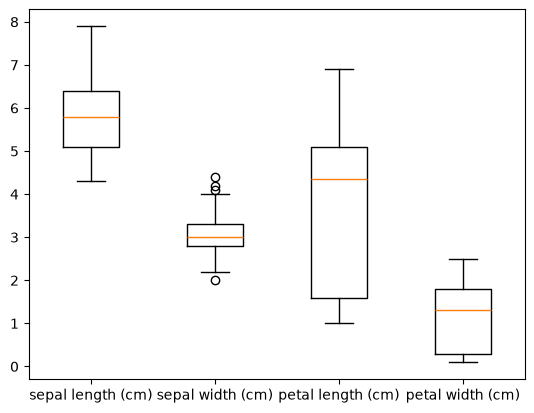

In [11]:
plt.boxplot(X, tick_labels= mydata.feature_names)

Text(0.5, 1.0, 'Boxplot de las características del iris')

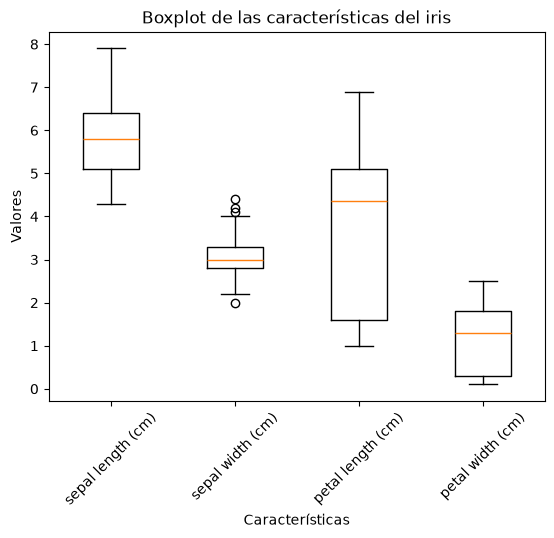

In [12]:
plt.boxplot(X)
plt.xticks([1, 2, 3, 4], mydata.feature_names, rotation=45)
plt.xlabel('Características')
plt.ylabel('Valores')
plt.title('Boxplot de las características del iris')

In [13]:
modeloDT = DecisionTreeClassifier()   # Incializamos el modelo con los hiperparámetros predeterminados.

#Aqui hacemos un metodo tradicional
clf = modeloDT.fit(X_train, y_train)   # Entrenamos con el conjunto de entrenamiento para obtener nuestro primer clasificador (clf)

# Podemos observar el desempeño en el conjunto de entrenamieto para verificar
# el subentrenamiento o sobreentrenamiento, pero no para evaluar el modelo en sí:
print('Exactitud en el conjunto de entrenamiento: %.2f' % clf.score(X_train, y_train))

# Así, el conjunto con el que nos interesa evaluar el desempeño es con los de validación,
# así que calculamos primero sus predicciones y después las usamos para evaluar el modelo:

predi = clf.predict(X_val)     # Obtenemos predicciones de 0s, 1s o 2s para cada clase

print('Exactitud en el conjunto de validación: %.2f' % clf.score(X_val, y_val))

Exactitud en el conjunto de entrenamiento: 1.00
Exactitud en el conjunto de validación: 0.97


Nos da 100% de accuracy y 97% de validacion

In [15]:
print(confusion_matrix(y_val, predi))

[[ 9  0  0]
 [ 0 10  0]
 [ 0  1 10]]


In [16]:
print(confusion_matrix(y_val,predi)/y_val.shape[0])

[[0.3        0.         0.        ]
 [0.         0.33333333 0.        ]
 [0.         0.03333333 0.33333333]]


Hay un 3.33% de error

In [18]:
clf.score(X_val,y_val)

0.9666666666666667

Sacando el score de validacion que tiene

In [19]:
pip install pydotplus

Defaulting to user installation because normal site-packages is not writeable
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for pydotplus: filename=pydotplus-2.0.2-py3-none-any.whl size=24659 sha256=7e5dd9287ebdf1f3a54cb488e51cd217c43799ba36054ab2d2adfdc5cada7146
  Stored in directory: c:\users\admin\appdata\local\packages\pythonsoftwarefoundation.python.3.13_qbz5n2kfra8p0\localcache\local\pip\cache\wheels\4a\c0\ed\a9eeeb08c3c53bb90d3822cf76557c8fdcbc349ee11a011169
Successfully built pydotplus
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\Admin\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [23]:
## Graficar el arbol de decision
from sklearn import tree
import pydotplus
from IPython.display import Image

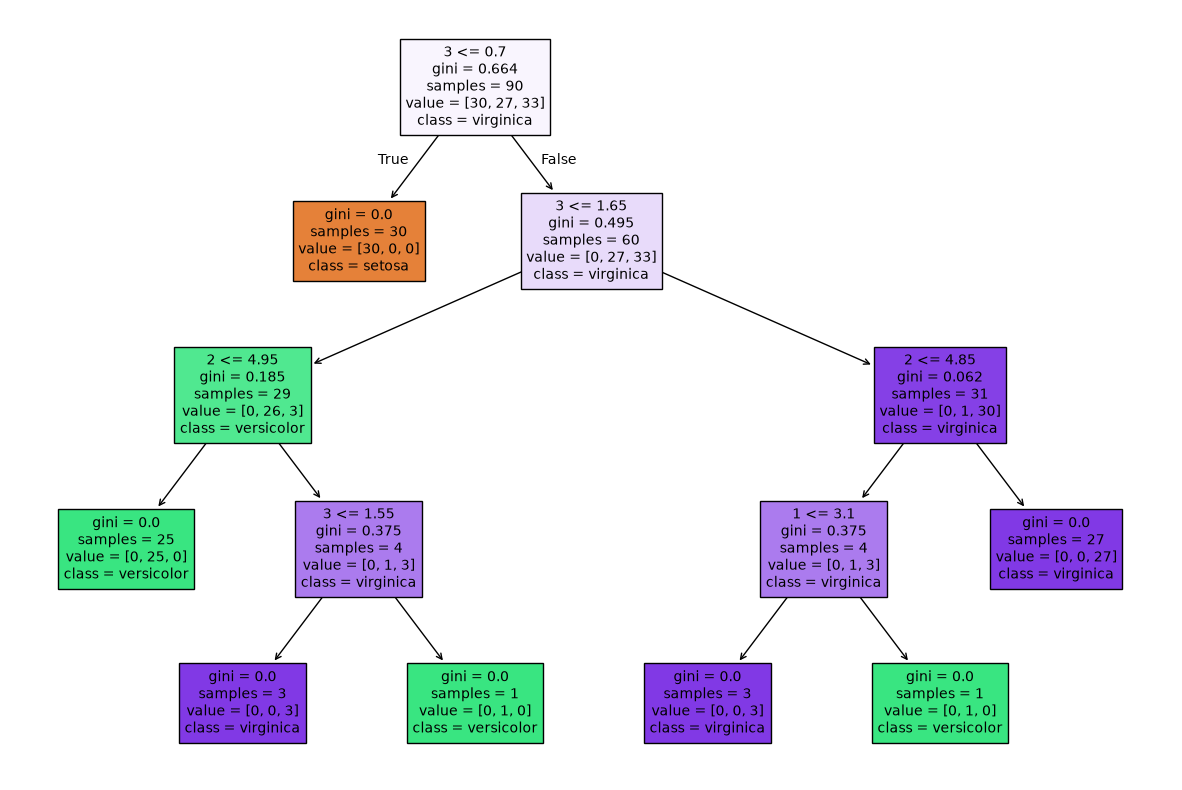

In [21]:
# 1. Configurar el tamaño de la imagen 
plt.figure(figsize=(15, 10)) 

# 2. Dibujar el árbol directamente 
tree.plot_tree(decision_tree=clf, 
                max_depth=None, 
                feature_names=list(pd.DataFrame(X_train).columns.astype(str)), 
                class_names=[str(c) for c in mydata.target_names], 
                filled=True, 
                proportion=False, 
                fontsize=10) 

# 3. Mostrar la imagen en Jupyter 
plt.show()

Como virginica es la clase mas general siempre va a indicar de entrada que lo es y llegaron 90 observaciones.
Ahora, en gini o mide la entropia o la pureza y si es 0 indica 100% de pureza, porque si 3 es menor a 0.7 es setosa. De lo contrario si es mayor a 0.7 es virginica pero se expande mas las ramas del arbol de decision. 


NOTA: Es importante considerar que entre a mayor profundidad del arbol mas probabilidad de sobreentrenamiento hay.

## Random Forest (Bosque Aleatorio)

In [28]:
import sklearn.datasets

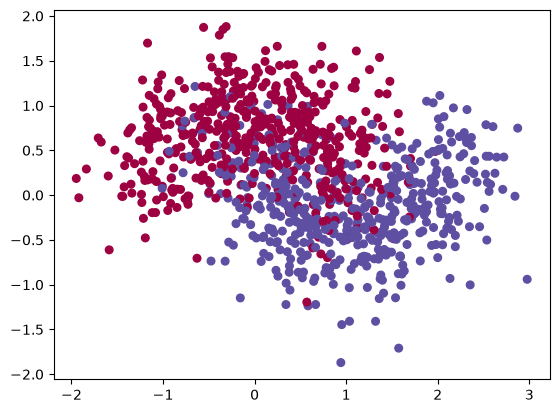

In [29]:
N=1000  # total de datos a generar en la muestra.
noisy_data = sklearn.datasets.make_moons(n_samples=N, noise=0.4, random_state=17)
X, Y = noisy_data

plt.scatter(X[:,0], X[:,1], c=Y, s=30, cmap=plt.cm.Spectral);

Hacemos dos clases, incluimos el ruido y generamos 1000 datos, Los datos estan muy revueltos, cada punto representa una clase diferente en sentido del color, se usa mucho este grafico para clusterizacion. 

In [30]:
Xtrain, Xtest, Ytrain, Ytest = train_test_split(X, Y, test_size=.4, shuffle=True, random_state=17)

mimodelo = RandomForestClassifier()
clf = mimodelo.fit(Xtrain,Ytrain)
results = clf.predict(Xtest)
confusion_matrix(Ytest, results)

array([[164,  38],
       [ 29, 169]])

In [31]:

clf.score(Xtest,Ytest)  # es la Exactitud (accuracy)

0.8325

In [32]:
clf.feature_importances_


array([0.45430693, 0.54569307])

Se grafica y observamos que la variable 2 es mas importante que la 1

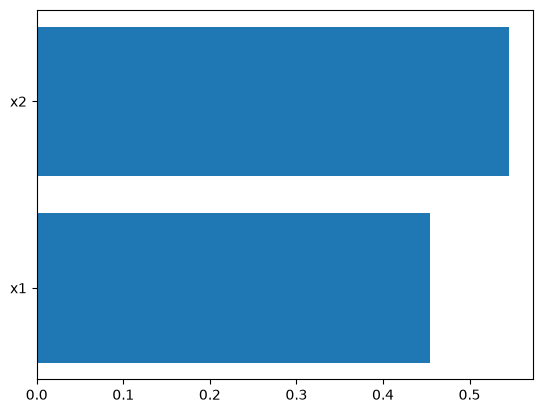

In [33]:
plt.barh(['x1','x2'], width=clf.feature_importances_);

In [40]:
## Algunos de lo hiperparámetros del clasificador bosque aleatorio:

mimodelo2 = RandomForestClassifier(n_estimators=10,  # número de árboles en el Forest y después promedia por votación.
                                   criterion='gini',   # métrica para determinar las ramas. También puede ser: 'entropy', para la GananciaDeInformación (IG).
                                   max_depth=2, # Depth=k : máximo 2^k líneas/ramas.        
                                   min_samples_split = 6,  # mínimo de puntos muestrales requeridos en un nodo para hacer la ramificación. Puede ser fracción de 0 a 1.
                                   min_samples_leaf = 4,  # mínimo de puntos muestrales que deben quedar en cada nueva ramificación (hojas). Puede ser fracción de 0 a 1.
                                   ## max_features= 'auto',   # número de características (features) que se consideran en cada ramificación: auto=sqrt(n_features).
                                   max_leaf_nodes=16,  # solo nos quedamos con las mejores k hojas.
                                   bootstrap=True,  # Cada Árbol se muestrea seleccionando la cantidad de datos del conjunto de entrenamiento, pero con reemplazo. False:los datos usados en cada árbol simpre es el mismo, el Train-set.
                                   oob_score=True,  # en caso de utilizar Out-of-bag samples.
                                   verbose=0,     # tipo de despliega de información durante el entrenamiento.
                                   n_jobs=-1,    # total de hilos a usar en las rutinas paralelizables: "-1" :usar todos los posibles. 
                                   max_samples=None,   # Cuando se usa Boostrap, es el total de datos de Xtrain a usar en cada árbol. "None" usará Xtrain[0]. 
                                   random_state=19)

In [41]:
clf2 = mimodelo2.fit(Xtrain,Ytrain)
clf2.score(Xtest,Ytest)

C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\ensemble\_forest.py:589: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


0.855